# Handwritten Digit Classification: kNN vs Feed-Forward Neural Networks

**Problem Statement:** Handwritten digit recognition is a classic supervised learning task. In this project, we compare two different approaches on the same data: a from-scratch k-nearest neighbors classifier and a from-scratch feed-forward neural network.

The following code is provided to help you get started. The default settings use a small built-in digits dataset so the notebook can run quickly on CPU. For a larger project, you can extend the same ideas to MNIST or another image classification dataset.


## 1. Install and Import Dependencies

In [ ]:
# !pip install scikit-learn matplotlib numpy tqdm
!pip install kagglehub #Jupiternote kaggle install
# %pip install kagglehub #VS Code kaagle install
import math
import random
import time
from collections import Counter
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


## 2. Load and Explore the Digits Dataset

The scikit-learn digits dataset contains 8 by 8 grayscale images of handwritten digits. Each image is flattened into 64 input features. Pixel values are normalized to the range 0 to 1.


Train: (200, 64), Validation: (80, 64), Test: (80, 64)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


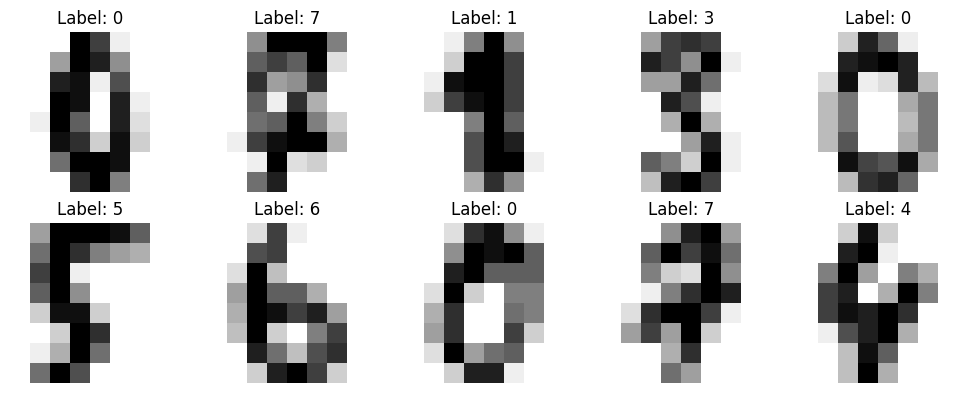

In [43]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.astype(int)

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Keep the default FFNN run quick. Increase these values for a stronger experiment.
TRAIN_LIMIT = 200
VAL_LIMIT = 80
TEST_LIMIT = 80

X_train = X_train_full[:TRAIN_LIMIT]
y_train = y_train_full[:TRAIN_LIMIT]
X_val = X_val_full[:VAL_LIMIT]
y_val = y_val_full[:VAL_LIMIT]
X_test = X_test_full[:TEST_LIMIT]
y_test = y_test_full[:TEST_LIMIT]

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {[int(label) for label in sorted(set(y))]}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), X_train[:10], y_train[:10]):
    ax.imshow(image.reshape(8, 8), cmap='gray_r')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. From-Scratch kNN Baseline

k-nearest neighbors classifies a new point by finding the most similar training examples. It does not learn weights during training; most of the work happens at prediction time.


In [44]:
def euclidean_distances(X_reference: np.ndarray, x_query: np.ndarray) -> np.ndarray:
    """Return the Euclidean distance from x_query to every row in X_reference."""
    differences = X_reference - x_query
    return np.sqrt(np.sum(differences * differences, axis=1))


def knn_predict_one(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    x_query: np.ndarray,
    k: int = 3,
) -> int:
    """Predict one label using majority vote among the k nearest examples."""
    distances = euclidean_distances(X_reference, x_query)
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_reference[nearest_indices]
    label_counts = Counter(nearest_labels)

    # Tie-break by choosing the smaller digit label for deterministic results.
    return min(label_counts, key=lambda label: (-label_counts[label], label))


def knn_predict(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    X_query: np.ndarray,
    k: int = 3,
) -> np.ndarray:
    """Predict labels for every row in X_query."""
    predictions = [knn_predict_one(X_reference, y_reference, row, k=k) for row in X_query]
    return np.array(predictions, dtype=int)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Return classification accuracy as a percentage."""
    return float(np.mean(y_true == y_pred) * 100.0)


In [45]:
knn_results = []
for k in [1, 3, 5, 7]:
    start = time.perf_counter()
    val_predictions = knn_predict(X_train, y_train, X_val, k=k)
    elapsed = time.perf_counter() - start
    val_acc = accuracy(y_val, val_predictions)
    knn_results.append({'k': k, 'val_accuracy': val_acc, 'seconds': elapsed})
    print(f"k={k}: validation accuracy={val_acc:.2f}% ({elapsed:.2f}s)")

best_knn = max(knn_results, key=lambda row: row['val_accuracy'])
best_k = best_knn['k']

start = time.perf_counter()
knn_test_predictions = knn_predict(X_train, y_train, X_test, k=best_k)
knn_test_time = time.perf_counter() - start
knn_test_accuracy = accuracy(y_test, knn_test_predictions)

print(f"\nBest k: {best_k}")
print(f"kNN test accuracy: {knn_test_accuracy:.2f}% ({knn_test_time:.2f}s)")


k=1: validation accuracy=93.75% (0.01s)
k=3: validation accuracy=92.50% (0.00s)
k=5: validation accuracy=91.25% (0.00s)
k=7: validation accuracy=86.25% (0.00s)

Best k: 1
kNN test accuracy: 97.50% (0.00s)


## 4. From-Scratch FFNN Baseline

A feed-forward neural network learns weights by adjusting them with gradient descent. The code below builds up a small computation graph: each scalar value records its data, its gradient, and how it was produced, so we can backpropagate by hand without PyTorch or TensorFlow.


In [46]:
def create_value(data: float, _children: Sequence[Dict] = (), _op: str = '') -> Dict:
    """Create one scalar Value node for the computation graph."""
    return {
        'data': float(data),
        'grad': 0.0,
        '_prev': list(_children),
        '_op': _op,
        '_backward': lambda: None,
    }


def add(a: Dict, b: Dict) -> Dict:
    out = create_value(a['data'] + b['data'], (a, b), '+')

    def _backward():
        a['grad'] += out['grad']
        b['grad'] += out['grad']

    out['_backward'] = _backward
    return out


def multiply(a: Dict, b: Dict) -> Dict:
    out = create_value(a['data'] * b['data'], (a, b), '*')

    def _backward():
        a['grad'] += b['data'] * out['grad']
        b['grad'] += a['data'] * out['grad']

    out['_backward'] = _backward
    return out


def power(a: Dict, exponent: float) -> Dict:
    out = create_value(a['data'] ** exponent, (a,), f'**{exponent}')

    def _backward():
        a['grad'] += exponent * (a['data'] ** (exponent - 1)) * out['grad']

    out['_backward'] = _backward
    return out


def relu(a: Dict) -> Dict:
    out = create_value(max(0.0, a['data']), (a,), 'relu')

    def _backward():
        a['grad'] += (1.0 if a['data'] > 0 else 0.0) * out['grad']

    out['_backward'] = _backward
    return out


def exp_op(a: Dict) -> Dict:
    clipped = max(min(a['data'], 50.0), -50.0)
    out = create_value(math.exp(clipped), (a,), 'exp')

    def _backward():
        a['grad'] += out['data'] * out['grad']

    out['_backward'] = _backward
    return out


def log_op(a: Dict) -> Dict:
    safe_value = max(a['data'], 1e-12)
    out = create_value(math.log(safe_value), (a,), 'log')

    def _backward():
        a['grad'] += (1.0 / safe_value) * out['grad']

    out['_backward'] = _backward
    return out


In [47]:
def softmax(logits: List[Dict]) -> List[Dict]:
    """Convert raw class scores into probabilities."""
    max_logit = max(node['data'] for node in logits)
    shifted = [add(node, create_value(-max_logit)) for node in logits]
    exp_values = [exp_op(node) for node in shifted]

    total = create_value(0.0)
    for value in exp_values:
        total = add(total, value)

    inv_total = power(total, -1.0)
    return [multiply(value, inv_total) for value in exp_values]


def initialize_model(
    input_size: int,
    layer_sizes: Sequence[int],
    activations: Sequence[str],
    seed: int = 0,
) -> Dict:
    """Create an MLP stored as dictionaries and lists."""
    rng = random.Random(seed)
    layers = []
    previous_size = input_size

    for layer_size, activation in zip(layer_sizes, activations):
        scale = math.sqrt(2.0 / previous_size) if activation == 'relu' else math.sqrt(1.0 / previous_size)
        neurons = []
        for _ in range(layer_size):
            weights = [create_value(rng.gauss(0.0, scale)) for _ in range(previous_size)]
            bias = create_value(0.0)
            neurons.append({'weights': weights, 'bias': bias})
        layers.append({'neurons': neurons, 'activation': activation})
        previous_size = layer_size

    return {'layers': layers}


def forward(model: Dict, x: Sequence[float]) -> List[Dict]:
    """Run one example through the MLP."""
    activations = [create_value(value) for value in x]

    for layer in model['layers']:
        linear_outputs = []
        for neuron in layer['neurons']:
            total = neuron['bias']
            for weight, activation in zip(neuron['weights'], activations):
                total = add(total, multiply(weight, activation))
            linear_outputs.append(total)

        if layer['activation'] == 'relu':
            activations = [relu(value) for value in linear_outputs]
        elif layer['activation'] == 'softmax':
            activations = softmax(linear_outputs)
        else:
            activations = linear_outputs

    return activations


def get_parameters(model: Dict) -> List[Dict]:
    """Return every trainable Value node in the model."""
    parameters = []
    for layer in model['layers']:
        for neuron in layer['neurons']:
            parameters.extend(neuron['weights'])
            parameters.append(neuron['bias'])
    return parameters


def cross_entropy_loss(probabilities: List[Dict], target_label: int) -> Dict:
    """Return -log(probability assigned to the correct class)."""
    return multiply(create_value(-1.0), log_op(probabilities[target_label]))


def backward(loss: Dict) -> None:
    """Backpropagate from loss through the computation graph."""
    topo = []
    visited = set()

    def build_topo(node: Dict):
        node_id = id(node)
        if node_id in visited:
            return
        visited.add(node_id)
        for parent in node.get('_prev', []):
            build_topo(parent)
        topo.append(node)

    build_topo(loss)
    loss['grad'] = 1.0
    for node in reversed(topo):
        node['_backward']()


In [48]:
def ffnn_predict_one(model: Dict, x: Sequence[float]) -> int:
    outputs = forward(model, x)
    return int(np.argmax([node['data'] for node in outputs]))


def ffnn_accuracy(model: Dict, X_eval: np.ndarray, y_eval: np.ndarray) -> float:
    predictions = [ffnn_predict_one(model, row) for row in X_eval]
    return accuracy(y_eval, np.array(predictions, dtype=int))


def average_loss(model: Dict, X_eval: np.ndarray, y_eval: np.ndarray) -> float:
    total_loss = 0.0
    for row, label in zip(X_eval, y_eval):
        outputs = forward(model, row)
        total_loss += cross_entropy_loss(outputs, int(label))['data']
    return total_loss / len(X_eval)


def train_ffnn(
    model: Dict,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = 5,
    learning_rate: float = 0.03,
) -> Dict[str, List[float]]:
    """Train the FFNN with stochastic gradient descent."""
    parameters = get_parameters(model)
    history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))
        epoch_loss = 0.0
        start = time.perf_counter()

        for idx in tqdm(indices, desc=f"Epoch {epoch + 1}/{epochs}", leave=False):
            for parameter in parameters:
                parameter['grad'] = 0.0

            outputs = forward(model, X_train[idx])
            loss = cross_entropy_loss(outputs, int(y_train[idx]))
            backward(loss)

            for parameter in parameters:
                parameter['data'] -= learning_rate * parameter['grad']

            epoch_loss += loss['data']

        train_loss = epoch_loss / len(X_train)
        train_eval_count = min(100, len(X_train))
        train_acc = ffnn_accuracy(model, X_train[:train_eval_count], y_train[:train_eval_count])
        val_loss = average_loss(model, X_val, y_val)
        val_acc = ffnn_accuracy(model, X_val, y_val)
        elapsed = time.perf_counter() - start

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch + 1}: train loss={train_loss:.3f}, "
            f"train acc={train_acc:.1f}%, val acc={val_acc:.1f}% ({elapsed:.1f}s)"
        )

    return history


In [49]:
ffnn_model = initialize_model(
    input_size=X_train.shape[1],
    layer_sizes=[16, 10],
    activations=['relu', 'softmax'],
    seed=SEED,
)
print(f"FFNN parameters: {len(get_parameters(ffnn_model))}")

ffnn_start = time.perf_counter()
ffnn_history = train_ffnn(
    ffnn_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=4,
    learning_rate=0.03,
)
ffnn_train_time = time.perf_counter() - ffnn_start
ffnn_test_accuracy = ffnn_accuracy(ffnn_model, X_test, y_test)

print(f"\nFFNN test accuracy: {ffnn_test_accuracy:.2f}%")
print(f"FFNN training time: {ffnn_train_time:.2f}s")


FFNN parameters: 1210


Epoch 1: train loss=2.116, train acc=50.0%, val acc=33.8% (9.9s)


Epoch 2: train loss=1.494, train acc=67.0%, val acc=52.5% (9.4s)


Epoch 3: train loss=0.975, train acc=75.0%, val acc=57.5% (9.1s)


Epoch 4: train loss=0.698, train acc=90.0%, val acc=73.8% (9.1s)

FFNN test accuracy: 78.75%
FFNN training time: 37.53s


In [ ]:
def plot_ffnn_history(history: Dict[str, List[float]]) -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='Train')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Train')
    axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_ffnn_history(ffnn_history)


## 5. Compare kNN and FFNN Results

Both models saw the same training, validation, and test split. kNN stores the training data and compares each test image to it. The FFNN spends time learning weights, then predicts with a fixed set of parameters.


In [ ]:
comparison = [
    {
        'model': f'kNN (k={best_k})',
        'validation_accuracy': best_knn['val_accuracy'],
        'test_accuracy': knn_test_accuracy,
        'time_seconds': knn_test_time,
        'notes': 'Prediction-time distance search',
    },
    {
        'model': 'FFNN (64 -> 16 -> 10)',
        'validation_accuracy': ffnn_history['val_accuracy'][-1],
        'test_accuracy': ffnn_test_accuracy,
        'time_seconds': ffnn_train_time,
        'notes': 'Training-time weight learning',
    },
]

print(f"{'Model':<24} {'Val Acc':>10} {'Test Acc':>10} {'Time (s)':>10}  Notes")
print('-' * 78)
for row in comparison:
    print(
        f"{row['model']:<24} "
        f"{row['validation_accuracy']:>9.2f}% "
        f"{row['test_accuracy']:>9.2f}% "
        f"{row['time_seconds']:>10.2f}  "
        f"{row['notes']}"
    )


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, true_label in zip(axes.ravel(), X_test[:10], y_test[:10]):
    knn_label = knn_predict_one(X_train, y_train, image, k=best_k)
    ffnn_label = ffnn_predict_one(ffnn_model, image)
    ax.imshow(image.reshape(8, 8), cmap='gray_r')
    ax.set_title(f"True {true_label}\nkNN {knn_label}, FFNN {ffnn_label}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 6. Experiment Ideas (BEFORE THIS CELL IS 8X8 MODEL TRAINING, AFTER IS FOR MNIST AND FILTERED DIGIT CASE TRAINING)
Use this notebook as a starting point for a project. Natural directions include:

- Try larger train, validation, and test limits. How do the two models scale?
- Try other values of `k` and different distance functions for kNN.
- Change the FFNN hidden layer size, learning rate, number of epochs, or activation function.
- Compare models on specific digits. Which classes are confused most often?
- Extend the notebook to MNIST, Fashion-MNIST, or another image classification dataset.
- Vectorize the FFNN with NumPy so it can train on more data faster.


In [ ]:
import kagglehub
import os
import struct

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)

def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Invalid magic number {magic} (expected 2051)"
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows * cols).astype(np.float64) / 255.0
    return images

def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Invalid magic number {magic} (expected 2049)"
        labels = np.frombuffer(f.read(), dtype=np.uint8).astype(int)
    return labels


def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"{filename} not found under {base_path}")

train_images_path = find_file(path, "train-images.idx3-ubyte")
train_labels_path = find_file(path, "train-labels.idx1-ubyte")
test_images_path  = find_file(path, "t10k-images.idx3-ubyte")
test_labels_path  = find_file(path, "t10k-labels.idx1-ubyte")

print("Using files:")
for p in [train_images_path, train_labels_path, test_images_path, test_labels_path]:
    print(" ", p)

# --- Load raw MNIST data ---

X_mnist_train = load_mnist_images(train_images_path)    # (60000, 784)
y_mnist_train = load_mnist_labels(train_labels_path)    # (60000,)       #BUGFIXED
X_mnist_test  = load_mnist_images(test_images_path)     # (10000, 784)  #BUGFIXED
y_mnist_test  = load_mnist_labels(test_labels_path)     # (10000,)

# Combine into a single pool, then re-split to get a validation set
X_all_mnist = np.concatenate([X_mnist_train, X_mnist_test], axis=0)
y_all_mnist = np.concatenate([y_mnist_train, y_mnist_test], axis=0)


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

X_train_full_mnist, X_temp_mnist, y_train_full_mnist, y_temp_mnist = train_test_split(
    X_all_mnist, y_all_mnist, test_size=0.30, random_state=SEED, stratify=y_all_mnist
)
X_val_full_mnist, X_test_full_mnist, y_val_full_mnist, y_test_full_mnist = train_test_split(
    X_temp_mnist, y_temp_mnist, test_size=0.50, random_state=SEED, stratify=y_temp_mnist
)

# Keep the default FFNN run quick. Increase these values for a stronger experiment.
# TRAIN_LIMIT = 200
# VAL_LIMIT = 80
# TEST_LIMIT = 80

# TWEAK parameters here
TRAIN_LIMIT = 2000
VAL_LIMIT = 800
TEST_LIMIT = 800

X_train_mnist = X_train_full_mnist[:TRAIN_LIMIT]
y_train_mnist = y_train_full_mnist[:TRAIN_LIMIT]
X_val_mnist = X_val_full_mnist[:VAL_LIMIT]
y_val_mnist = y_val_full_mnist[:VAL_LIMIT]
X_test_mnist = X_test_full_mnist[:TEST_LIMIT]
y_test_mnist = y_test_full_mnist[:TEST_LIMIT]

print(f"\nTrain: {X_train_mnist.shape}, Validation: {X_val_mnist.shape}, Test: {X_test_mnist.shape}")
print(f"Classes: {[int(label) for label in sorted(set(y_all_mnist))]}")

# fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# for ax, image, label in zip(axes.ravel(), X_train_mnist[:10], y_train_mnist[:10]):
#     ax.imshow(image.reshape(28, 28), cmap='gray_r')   # 8×8 -> 28×28(MNIST)
#     ax.set_title(f"Label: {label}")
#     ax.axis('off')
# plt.tight_layout()
# plt.show()


In [ ]:
def euclidean_distances(X_reference: np.ndarray, x_query: np.ndarray) -> np.ndarray:
    """Return the Euclidean distance from x_query to every row in X_reference."""
    differences = X_reference - x_query
    return np.sqrt(np.sum(differences * differences, axis=1))


def knn_predict_one(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    x_query: np.ndarray,
    k: int = 3,
) -> int:
    """Predict one label using majority vote among the k nearest examples."""
    distances = euclidean_distances(X_reference, x_query)
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_reference[nearest_indices]
    label_counts = Counter(nearest_labels)

    # Tie-break by choosing the smaller digit label for deterministic results.
    return min(label_counts, key=lambda label: (-label_counts[label], label))


def knn_predict(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    X_query: np.ndarray,
    k: int = 3,
) -> np.ndarray:
    """Predict labels for every row in X_query."""
    predictions = [knn_predict_one(X_reference, y_reference, row, k=k) for row in X_query]
    return np.array(predictions, dtype=int)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Return classification accuracy as a percentage."""
    return float(np.mean(y_true == y_pred) * 100.0)


In [ ]:
knn_results = []
for k in [1, 3, 5, 7]:
    start = time.perf_counter()
    val_predictions = knn_predict(X_train_mnist, y_train_mnist, X_val_mnist, k=k)
    elapsed = time.perf_counter() - start
    val_acc = accuracy(y_val_mnist, val_predictions)
    knn_results.append({'k': k, 'val_accuracy': val_acc, 'seconds': elapsed})
    print(f"k={k}: validation accuracy={val_acc:.2f}% ({elapsed:.2f}s)")

best_knn = max(knn_results, key=lambda row: row['val_accuracy'])
best_k = best_knn['k']

start = time.perf_counter()
knn_test_predictions = knn_predict(X_train_mnist, y_train_mnist, X_test_mnist, k=best_k)
knn_test_time = time.perf_counter() - start
knn_test_accuracy = accuracy(y_test_mnist, knn_test_predictions)

print(f"\nBest k: {best_k}")
print(f"kNN test accuracy: {knn_test_accuracy:.2f}% ({knn_test_time:.2f}s)")


In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Device setup ---
# if(not torch.backends.mps.is_available()):
#     raise ValueError("Model using cpu")
    
device = torch.device("cpu")

SEED = 42
torch.manual_seed(SEED)


# --- Model definition (mirrors your [784 -> 16 -> relu -> 10 -> softmax] arch) ---

def initialize_model_torch(input_size: int, layer_sizes, activations, seed=0):
    torch.manual_seed(seed)
    layers = []
    prev_size = input_size

    for size, act in zip(layer_sizes, activations):
        linear = nn.Linear(prev_size, size)

        # Match your initialization scheme
        if act == 'relu':
            nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')  # He init = sqrt(2/n)
        else:
            nn.init.xavier_uniform_(linear.weight)                        # Glorot = sqrt(1/n)
        nn.init.zeros_(linear.bias)

        layers.append(linear)

        if act == 'relu':
            layers.append(nn.ReLU())
        # softmax is handled in the loss (see below)

        prev_size = size

    return nn.Sequential(*layers).to(device)


# --- Training --- #TWEAK PARAMETERS HERE

def train_ffnn_torch(
    model,
    X_train, y_train,
    X_val,   y_val,
    epochs=4,
    learning_rate=0.03,
    batch_size=32,
):
    # Convert numpy → tensors on MPS
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.long).to(device)
    X_v  = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_v  = torch.tensor(y_val,   dtype=torch.long).to(device)

    # CrossEntropyLoss = log_softmax + NLLLoss, so no explicit softmax needed in forward
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loader    = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        start = time.perf_counter()

        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)

        # --- Evaluation (no grad needed) ---
        model.eval()
        with torch.no_grad():
            train_logits = model(X_tr)
            train_loss   = criterion(train_logits, y_tr).item()
            train_acc    = (train_logits.argmax(dim=1) == y_tr).float().mean().item() * 100

            val_logits = model(X_v)
            val_loss   = criterion(val_logits, y_v).item()
            val_acc    = (val_logits.argmax(dim=1) == y_v).float().mean().item() * 100

        elapsed = time.perf_counter() - start
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}: train loss={train_loss:.3f}, "
            f"train acc={train_acc:.1f}%, val acc={val_acc:.1f}% ({elapsed:.1f}s)"
        )

    return history


# --- Predict / accuracy helpers (same interface as before) ---

def ffnn_predict_one_torch(model, x):
    model.eval()
    with torch.no_grad():
        t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        return int(model(t).argmax(dim=1).item())

def ffnn_accuracy_torch(model, X_eval, y_eval):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_eval, dtype=torch.float32).to(device)
        y_t = torch.tensor(y_eval, dtype=torch.long).to(device)
        preds = model(X_t).argmax(dim=1)
        return (preds == y_t).float().mean().item() * 100

In [ ]:
# Running Model

ffnn_model_mnist = initialize_model_torch(
    input_size=X_train_mnist.shape[1],   # 784 for MNIST
    layer_sizes=[16, 10],
    activations=['relu', 'softmax'],
    seed=SEED,
)
print(f"FFNN parameters: {sum(p.numel() for p in ffnn_model_mnist.parameters())}")

ffnn_start_mnist = time.perf_counter()
ffnn_history_mnist = train_ffnn_torch(
    ffnn_model_mnist,
    X_train_mnist, y_train_mnist,
    X_val_mnist,   y_val_mnist,
    epochs=4,
    learning_rate=0.03,
    batch_size=32,
)
ffnn_train_time_mnist = time.perf_counter() - ffnn_start_mnist
ffnn_test_accuracy_mnist = ffnn_accuracy_torch(ffnn_model_mnist, X_test_mnist, y_test_mnist)

print(f"\nFFNN test accuracy: {ffnn_test_accuracy_mnist:.2f}%")
print(f"FFNN training time: {ffnn_train_time_mnist:.2f}s")

In [ ]:
def plot_ffnn_history(history: Dict[str, List[float]]) -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='Train')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Train')
    axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_ffnn_history(ffnn_history_mnist)


## 7. Removing Digits (MNIST) To Tweak parameters(eg. learning rate, epoch, batch_sizes) Go to Step 6.


In [ ]:
DIGITS_TO_REMOVE = {2, 7}  # ← change this set to remove any combination of digits

def filter_digits(X: np.ndarray, y: np.ndarray, digits_to_remove: set) -> tuple:
    """Remove samples belonging to specified digit classes."""
    mask = ~np.isin(y, list(digits_to_remove))
    return X[mask], y[mask]


X_rdigit, y_rdigit = filter_digits(X_all_mnist, y_all_mnist, DIGITS_TO_REMOVE)

print(f"Original : {X_all_mnist.shape[0]:,} samples, classes {sorted(set(y_all_mnist))}")
print(f"Filtered : {X_rdigit.shape[0]:,} samples, classes {sorted(set(y_rdigit))}")

X_train_full_rdigit, X_temp_rdigit, y_train_full_rdigit, y_temp_rdigit = train_test_split(
    X_rdigit, y_rdigit, test_size=0.30, random_state=SEED, stratify=y_rdigit
)
X_val_full_rdigit, X_test_full_rdigit, y_val_full_rdigit, y_test_full_rdigit = train_test_split(
    X_temp_rdigit, y_temp_rdigit, test_size=0.50, random_state=SEED, stratify=y_temp_rdigit
)

X_train_rdigit = X_train_full_rdigit[:TRAIN_LIMIT]
X_val_rdigit   = X_val_full_rdigit[:VAL_LIMIT]
X_test_rdigit  = X_test_full_rdigit[:TEST_LIMIT]

# Remap labels to contiguous 0..N-1 so CrossEntropyLoss doesn't go out of bounds
remaining_classes_rdigit = sorted(set(y_rdigit))
label_map = {old: new for new, old in enumerate(remaining_classes_rdigit)}

def remap_labels(y, label_map):
    return np.array([label_map[label] for label in y], dtype=int)

y_train_rdigit = remap_labels(y_train_full_rdigit[:TRAIN_LIMIT], label_map)
y_val_rdigit   = remap_labels(y_val_full_rdigit[:VAL_LIMIT],   label_map)
y_test_rdigit  = remap_labels(y_test_full_rdigit[:TEST_LIMIT],  label_map)

print(f"\nTrain: {X_train_rdigit.shape}, Validation: {X_val_rdigit.shape}, Test: {X_test_rdigit.shape}")
print(f"Classes: {sorted(set(y_rdigit))}")



In [ ]:
# KNN

knn_results = []
for k in [1, 3, 5, 7]:
    start = time.perf_counter()
    val_predictions = knn_predict(X_train_rdigit, y_train_rdigit, X_val_rdigit, k=k)
    elapsed = time.perf_counter() - start
    val_acc = accuracy(y_val_rdigit, val_predictions)
    knn_results.append({'k': k, 'val_accuracy': val_acc, 'seconds': elapsed})
    print(f"k={k}: validation accuracy={val_acc:.2f}% ({elapsed:.2f}s)")

best_knn_rdigit = max(knn_results, key=lambda row: row['val_accuracy'])
best_k_rdigit = best_knn_rdigit['k']

start = time.perf_counter()
knn_test_predictions_rdigit = knn_predict(X_train_rdigit, y_train_rdigit, X_test_rdigit, k=best_k_rdigit)
knn_test_time_rdigit = time.perf_counter() - start
knn_test_accuracy_rdigit = accuracy(y_test_rdigit, knn_test_predictions_rdigit)

print(f"\nBest k: {best_k_rdigit}")
print(f"kNN test accuracy: {knn_test_accuracy_rdigit:.2f}% ({knn_test_time_rdigit:.2f}s)")

In [ ]:
# Running

remaining_classes_rdigit = sorted(set(y_rdigit))
num_classes_rdigit = len(remaining_classes_rdigit)

ffnn_model_rdigit = initialize_model_torch(
    input_size=X_train_rdigit.shape[1],
    layer_sizes=[16, num_classes_rdigit],
    activations=['relu', 'softmax'],
    seed=SEED,
)
print(f"FFNN parameters: {sum(p.numel() for p in ffnn_model_rdigit.parameters())}")

ffnn_start_rdigit = time.perf_counter()
ffnn_history_rdigit = train_ffnn_torch(
    ffnn_model_rdigit,
    X_train_rdigit, y_train_rdigit,
    X_val_rdigit,   y_val_rdigit,
    epochs=4,
    learning_rate=0.03,
    batch_size=32,
)
ffnn_train_time_rdigit = time.perf_counter() - ffnn_start_rdigit
ffnn_test_accuracy_rdigit = ffnn_accuracy_torch(ffnn_model_rdigit, X_test_rdigit, y_test_rdigit)

print(f"\nFFNN test accuracy: {ffnn_test_accuracy_rdigit:.2f}%")
print(f"FFNN training time: {ffnn_train_time_rdigit:.2f}s")

plot_ffnn_history(ffnn_history_rdigit)

## 8.5 Removing Digits (8x8) To Tweak parameters(eg. learning rate, epoch, batch_sizes) Go back to step 2-5.


In [ ]:
#Filters Digits for (8x8)
DIGITS_TO_REMOVE_SMALL = {2, 7}  # ← change as needed

X_all_small = np.concatenate([X_train_full, X_val_full, X_test_full], axis=0)
y_all_small = np.concatenate([y_train_full, y_val_full, y_test_full], axis=0)

X_rdigit_small, y_rdigit_small = filter_digits(X_all_small, y_all_small, DIGITS_TO_REMOVE_SMALL)

print(f"Original : {X_all_small.shape[0]:,} samples, classes {sorted(set(y_all_small))}")
print(f"Filtered : {X_rdigit_small.shape[0]:,} samples, classes {sorted(set(y_rdigit_small))}")

X_train_full_rs, X_temp_rs, y_train_full_rs, y_temp_rs = train_test_split(
    X_rdigit_small, y_rdigit_small, test_size=0.30, random_state=SEED, stratify=y_rdigit_small
)
X_val_full_rs, X_test_full_rs, y_val_full_rs, y_test_full_rs = train_test_split(
    X_temp_rs, y_temp_rs, test_size=0.50, random_state=SEED, stratify=y_temp_rs
)

X_train_rs = X_train_full_rs[:TRAIN_LIMIT]
X_val_rs   = X_val_full_rs[:VAL_LIMIT]
X_test_rs  = X_test_full_rs[:TEST_LIMIT]

# Remap labels to contiguous 0..N-1
remaining_classes_rs = sorted(set(y_rdigit_small))
label_map_rs = {old: new for new, old in enumerate(remaining_classes_rs)}

y_train_rs = remap_labels(y_train_full_rs[:TRAIN_LIMIT], label_map_rs)
y_val_rs   = remap_labels(y_val_full_rs[:VAL_LIMIT],     label_map_rs)
y_test_rs  = remap_labels(y_test_full_rs[:TEST_LIMIT],   label_map_rs)

print(f"\nTrain: {X_train_rs.shape}, Validation: {X_val_rs.shape}, Test: {X_test_rs.shape}")
print(f"Classes: {remaining_classes_rs}")


In [ ]:
#FFNN Model (Filtered 8x8)

knn_results_rs = []
for k in [1, 3, 5, 7]:
    start = time.perf_counter()
    val_predictions = knn_predict(X_train_rs, y_train_rs, X_val_rs, k=k)
    elapsed = time.perf_counter() - start
    val_acc = accuracy(y_val_rs, val_predictions)
    knn_results_rs.append({'k': k, 'val_accuracy': val_acc, 'seconds': elapsed})
    print(f"k={k}: validation accuracy={val_acc:.2f}% ({elapsed:.2f}s)")

best_knn_rs = max(knn_results_rs, key=lambda row: row['val_accuracy'])
best_k_rs = best_knn_rs['k']

start = time.perf_counter()
knn_test_predictions_rs = knn_predict(X_train_rs, y_train_rs, X_test_rs, k=best_k_rs)
knn_test_time_rs = time.perf_counter() - start
knn_test_accuracy_rs = accuracy(y_test_rs, knn_test_predictions_rs)

print(f"\nBest k: {best_k_rs}")
print(f"kNN test accuracy: {knn_test_accuracy_rs:.2f}% ({knn_test_time_rs:.2f}s)")

In [ ]:
#FFNN Model (Filtered 8x8)

num_classes_rs = len(remaining_classes_rs)

ffnn_model_rs = initialize_model_torch(
    input_size=X_train_rs.shape[1],   # 64 for 8x8
    layer_sizes=[16, num_classes_rs],
    activations=['relu', 'softmax'],
    seed=SEED,
)
print(f"FFNN parameters: {sum(p.numel() for p in ffnn_model_rs.parameters())}")

ffnn_start_rs = time.perf_counter()
ffnn_history_rs = train_ffnn_torch(
    ffnn_model_rs,
    X_train_rs, y_train_rs,
    X_val_rs,   y_val_rs,
    epochs=4,
    learning_rate=0.03,
    batch_size=32,
)
ffnn_train_time_rs = time.perf_counter() - ffnn_start_rs
ffnn_test_accuracy_rs = ffnn_accuracy_torch(ffnn_model_rs, X_test_rs, y_test_rs)

print(f"\nFFNN test accuracy: {ffnn_test_accuracy_rs:.2f}%")
print(f"FFNN training time: {ffnn_train_time_rs:.2f}s")

plot_ffnn_history(ffnn_history_rs)

## 9. 8x8 Model Training

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.astype(int)

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Keep the default FFNN run quick. Increase these values for a stronger experiment.
TRAIN_LIMIT = 200
VAL_LIMIT = 80
TEST_LIMIT = 80

X_train = X_train_full[:TRAIN_LIMIT]
y_train = y_train_full[:TRAIN_LIMIT]
X_val = X_val_full[:VAL_LIMIT]
y_val = y_val_full[:VAL_LIMIT]
X_test = X_test_full[:TEST_LIMIT]
y_test = y_test_full[:TEST_LIMIT]

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {[int(label) for label in sorted(set(y))]}")

# fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# for ax, image, label in zip(axes.ravel(), X_train[:10], y_train[:10]):
#     ax.imshow(image.reshape(8, 8), cmap='gray_r')
#     ax.set_title(f"Label: {label}")
#     ax.axis('off')
# plt.tight_layout()
# plt.show()


Train: (1200, 64), Validation: (80, 64), Test: (80, 64)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
# Running Model

ffnn_model_8x8 = initialize_model_torch(
    input_size=X_train.shape[1],
    layer_sizes=[32, 16, 10],
    activations=['relu', 'softmax'],
    seed=SEED,
)
print(f"FFNN parameters: {sum(p.numel() for p in ffnn_model_8x8.parameters())}")

ffnn_start_8x8 = time.perf_counter()
ffnn_history_8x8 = train_ffnn_torch(
    ffnn_model_8x8,
    X_train, y_train,
    X_val,   y_val,
    epochs=40,
    learning_rate=0.03,
    batch_size=32,
)
ffnn_train_time_8x8 = time.perf_counter() - ffnn_start_8x8
ffnn_test_accuracy_8x8 = ffnn_accuracy_torch(ffnn_model_8x8, X_test, y_test)

print(f"\nFFNN test accuracy: {ffnn_test_accuracy_8x8:.2f}%")
print(f"FFNN training time: {ffnn_train_time_8x8:.2f}s")

FFNN parameters: 1210
Epoch 1: train loss=2.196, train acc=21.1%, val acc=25.0% (0.1s)
Epoch 2: train loss=2.030, train acc=36.0%, val acc=35.0% (0.0s)
Epoch 3: train loss=1.877, train acc=46.4%, val acc=43.8% (0.0s)
Epoch 4: train loss=1.715, train acc=57.1%, val acc=53.8% (0.0s)
Epoch 5: train loss=1.549, train acc=66.8%, val acc=67.5% (0.0s)
Epoch 6: train loss=1.384, train acc=72.4%, val acc=71.2% (0.0s)
Epoch 7: train loss=1.225, train acc=77.2%, val acc=77.5% (0.0s)
Epoch 8: train loss=1.085, train acc=81.0%, val acc=80.0% (0.0s)
Epoch 9: train loss=0.965, train acc=82.3%, val acc=85.0% (0.0s)
Epoch 10: train loss=0.861, train acc=85.1%, val acc=83.7% (0.0s)
Epoch 11: train loss=0.773, train acc=86.7%, val acc=87.5% (0.0s)
Epoch 12: train loss=0.703, train acc=87.4%, val acc=87.5% (0.0s)
Epoch 13: train loss=0.638, train acc=88.8%, val acc=88.7% (0.0s)
Epoch 14: train loss=0.587, train acc=89.2%, val acc=90.0% (0.0s)
Epoch 15: train loss=0.541, train acc=89.7%, val acc=87.5% (0.0

In [78]:
def euclidean_distances(X_reference: np.ndarray, x_query: np.ndarray) -> np.ndarray:
    """Return the Euclidean distance from x_query to every row in X_reference."""
    differences = X_reference - x_query
    return np.sqrt(np.sum(differences * differences, axis=1))


def knn_predict_one(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    x_query: np.ndarray,
    k: int = 3,
) -> int:
    """Predict one label using majority vote among the k nearest examples."""
    distances = euclidean_distances(X_reference, x_query)
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_reference[nearest_indices]
    label_counts = Counter(nearest_labels)

    # Tie-break by choosing the smaller digit label for deterministic results.
    return min(label_counts, key=lambda label: (-label_counts[label], label))


def knn_predict(
    X_reference: np.ndarray,
    y_reference: np.ndarray,
    X_query: np.ndarray,
    k: int = 3,
) -> np.ndarray:
    """Predict labels for every row in X_query."""
    predictions = [knn_predict_one(X_reference, y_reference, row, k=k) for row in X_query]
    return np.array(predictions, dtype=int)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Return classification accuracy as a percentage."""
    return float(np.mean(y_true == y_pred) * 100.0)


In [79]:
knn_results = []
for k in [1, 3, 5, 7]:
    start = time.perf_counter()
    val_predictions = knn_predict(X_train, y_train, X_val, k=k)
    elapsed = time.perf_counter() - start
    val_acc = accuracy(y_val, val_predictions)
    knn_results.append({'k': k, 'val_accuracy': val_acc, 'seconds': elapsed})
    print(f"k={k}: validation accuracy={val_acc:.2f}% ({elapsed:.2f}s)")

best_knn = max(knn_results, key=lambda row: row['val_accuracy'])
best_k = best_knn['k']

start = time.perf_counter()
knn_test_predictions = knn_predict(X_train, y_train, X_test, k=best_k)
knn_test_time = time.perf_counter() - start
knn_test_accuracy = accuracy(y_test, knn_test_predictions)

print(f"\nBest k: {best_k}")
print(f"kNN test accuracy: {knn_test_accuracy:.2f}% ({knn_test_time:.2f}s)")


k=1: validation accuracy=95.00% (0.03s)
k=3: validation accuracy=95.00% (0.05s)
k=5: validation accuracy=95.00% (0.02s)
k=7: validation accuracy=96.25% (0.01s)

Best k: 7
kNN test accuracy: 100.00% (0.01s)


In [ ]:
def plot_ffnn_history(history: Dict[str, List[float]]) -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='Train')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Train')
    axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_ffnn_history(ffnn_history_mnist)
